In [1]:
!date

Mon Sep 14 07:49:45 PDT 2026


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

projdir = '/u/project/cluo/terencew/claude/project_ideas/pool_design'

In [3]:
### load per-droplet scores (from 01a) and pool design metrics (from pool_nomination.py)
scored = pd.read_csv(f'{projdir}/csv/ambisim/droplet_scores.csv', sep='\t')
scored.head()

,pool,universe,strategy,rep,modality,barcode,is_true_singlet,called_singlet,correct,ambient_frac,ll_gap,called_donor,true_donor
0,AFR_only__adversarial_mindist__rep1,AFR_only,adversarial_mindist,1,gex,AAACAGCCAAACAACA,True,True,True,0.098320,15.04,HG03461,HG03461
1,AFR_only__adversarial_mindist__rep1,AFR_only,adversarial_mindist,1,gex,AAACAGCCAAACATAG,True,True,True,0.156914,10.97,NA18924,NA18924
2,AFR_only__adversarial_mindist__rep1,AFR_only,adversarial_mindist,1,gex,AAACAGCCAAACCCTA,True,False,False,0.391450,0.00,HG03520,HG03520
3,AFR_only__adversarial_mindist__rep1,AFR_only,adversarial_mindist,1,gex,AAACAGCCAAACCTAT,True,False,False,0.314493,0.00,NA18933,NA18933
4,AFR_only__adversarial_mindist__rep1,AFR_only,adversarial_mindist,1,gex,AAACAGCCAAACCTTG,True,True,True,0.184638,20.95,NA19150,NA19150


In [4]:
scored.shape

(1583824, 13)

In [5]:
### quick report: mean droplet accuracy per pool, restricted to true singlets
sng = scored[scored['is_true_singlet']]
acc = sng.groupby(['pool', 'universe', 'strategy', 'modality'])['correct'].mean().reset_index()
acc_wide = acc.pivot_table(index=['pool', 'universe', 'strategy'], columns='modality', values='correct').reset_index()
acc_wide = acc_wide.sort_values('gex', ascending=False)
acc_wide

modality,pool,universe,strategy,atac,gex
41,EUR_AFR__greedy_maxmin__rep3,EUR_AFR,greedy_maxmin,0.919373,0.859983
50,EUR_EAS__random__rep2,EUR_EAS,random,0.918755,0.859242
77,all_3_major__greedy_maxmean__rep1,all_3_major,greedy_maxmean,0.923324,0.858871
86,all_5__greedy_maxmin__rep1,all_5,greedy_maxmin,0.924435,0.857266
38,EUR_AFR__greedy_maxmean__rep2,EUR_AFR,greedy_maxmean,0.918385,0.856525
...,...,...,...,...,...
84,all_5__ancestry_balanced__rep2,all_5,ancestry_balanced,0.925670,0.816521
53,EUR_only__adversarial_family__rep2,EUR_only,adversarial_family,0.910359,0.811829
8,AFR_only__random__rep1,AFR_only,random,0.919867,0.809359
32,EUR_AFR__adversarial_family_mixed__rep2,EUR_AFR,adversarial_family_mixed,0.906779,0.808248


In [6]:
acc_wide[['gex', 'atac']].describe()

modality,gex,atac
count,88.000000,88.000000
mean,0.840321,0.916896
std,0.012335,0.004794
min,0.799111,0.903445
25%,0.833498,0.913940
50%,0.843005,0.917335
75%,0.848407,0.919898
max,0.859983,0.925670


In [7]:
### merge in pool design metrics: kl_min/kl_mean (KL divergence, mechanistically tied
### to demuxlet's own genotype LR) and min_dist (the metric CLAUDE.md notes as
### marginally best-correlated with real-data singlet rate so far)
design = pd.read_csv(f'{projdir}/csv/designs/nominated_pools_n8.tsv', sep='\t')
design['pool'] = design['universe'] + '__' + design['strategy'] + '__rep' + design['rep'].astype(str)
design = design.drop_duplicates('pool')[['pool', 'min_dist', 'kl_min', 'kl_mean']]

acc_design = acc_wide.merge(design, on='pool', how='left')
print('unmatched pools:', acc_design['min_dist'].isna().sum())
acc_design.head()

unmatched pools: 0


,pool,universe,strategy,atac,gex,min_dist,kl_min,kl_mean
0,EUR_AFR__greedy_maxmin__rep3,EUR_AFR,greedy_maxmin,0.919373,0.859983,114.825960,2.276969,2.628722
1,EUR_EAS__random__rep2,EUR_EAS,random,0.918755,0.859242,93.284510,1.502782,2.060164
2,all_3_major__greedy_maxmean__rep1,all_3_major,greedy_maxmean,0.923324,0.858871,109.155850,2.057648,2.815293
3,all_5__greedy_maxmin__rep1,all_5,greedy_maxmin,0.924435,0.857266,118.321594,2.417714,2.869019
4,EUR_AFR__greedy_maxmean__rep2,EUR_AFR,greedy_maxmean,0.918385,0.856525,109.128365,2.056611,2.693784


In [8]:
### Tier-1 margin metrics from md/analyses.md: LL-gap left tail (5th pct) and
### low-margin fraction, computed on true singlets that demuxlet also called singlet
called_sng = scored[scored['is_true_singlet'] & scored['called_singlet']]

def summarize_group(g):
    return pd.Series({
        'll_gap_p5': np.percentile(g['ll_gap'], 5),
        'll_gap_mean': g['ll_gap'].mean(),
        'low_margin_frac_t50': (g['ll_gap'] < 50).mean(),
        'low_margin_frac_t100': (g['ll_gap'] < 100).mean(),
        'n_singlets': len(g),
    })

margin = called_sng.groupby(['pool', 'universe', 'strategy', 'modality']).apply(summarize_group).reset_index()
margin.head()

/tmp/ipykernel_7903/949442909.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  margin = called_sng.groupby(['pool', 'universe', 'strategy', 'modality']).apply(summarize_group).reset_index()


,pool,universe,strategy,modality,ll_gap_p5,ll_gap_mean,low_margin_frac_t50,low_margin_frac_t100,n_singlets
0,AFR_only__adversarial_mindist__rep1,AFR_only,adversarial_mindist,atac,1.28,27.414383,0.856719,0.972233,7419.0
1,AFR_only__adversarial_mindist__rep1,AFR_only,adversarial_mindist,gex,-0.81,10.133407,0.988501,0.999403,6696.0
2,AFR_only__adversarial_mindist__rep2,AFR_only,adversarial_mindist,atac,1.19,27.384549,0.862246,0.972638,7419.0
3,AFR_only__adversarial_mindist__rep2,AFR_only,adversarial_mindist,gex,-0.82,9.803743,0.989594,0.999698,6631.0
4,AFR_only__greedy_maxkl__rep2,AFR_only,greedy_maxkl,atac,1.52,27.517890,0.857430,0.972774,7456.0


In [9]:
### assemble one row per pool x modality: accuracy + margin + design score
summary = acc.rename(columns={'correct': 'accuracy'}).merge(
    margin, on=['pool', 'universe', 'strategy', 'modality'])
summary = summary.merge(design, on='pool', how='left')
summary.head()

,pool,universe,strategy,modality,accuracy,ll_gap_p5,ll_gap_mean,low_margin_frac_t50,low_margin_frac_t100,n_singlets,min_dist,kl_min,kl_mean
0,AFR_only__adversarial_mindist__rep1,AFR_only,adversarial_mindist,atac,0.915916,1.28,27.414383,0.856719,0.972233,7419.0,100.000000,1.406993,1.504039
1,AFR_only__adversarial_mindist__rep1,AFR_only,adversarial_mindist,gex,0.825904,-0.81,10.133407,0.988501,0.999403,6696.0,100.000000,1.406993,1.504039
2,AFR_only__adversarial_mindist__rep2,AFR_only,adversarial_mindist,atac,0.916039,1.19,27.384549,0.862246,0.972638,7419.0,99.779755,1.382161,1.473907
3,AFR_only__adversarial_mindist__rep2,AFR_only,adversarial_mindist,gex,0.818373,-0.82,9.803743,0.989594,0.999698,6631.0,99.779755,1.382161,1.473907
4,AFR_only__greedy_maxkl__rep2,AFR_only,greedy_maxkl,atac,0.920484,1.52,27.517890,0.857430,0.972774,7456.0,112.565536,1.678527,1.935700


In [10]:
### correlate margin / accuracy against pool design metrics, per modality
for modality in ['gex', 'atac']:
    sub = summary[summary['modality'] == modality]
    for metric in ['accuracy', 'll_gap_p5', 'll_gap_mean', 'low_margin_frac_t100']:
        r_dist, p_dist = pearsonr(sub['min_dist'], sub[metric])
        r_kl, p_kl = pearsonr(sub['kl_min'], sub[metric])
        print(f'{modality:5s} min_dist vs {metric:22s} r={r_dist:+.3f} p={p_dist:.3f}   '
              f'kl_min vs {metric:22s} r={r_kl:+.3f} p={p_kl:.3f}')

gex   min_dist vs accuracy               r=+0.349 p=0.001   kl_min vs accuracy               r=+0.399 p=0.000
gex   min_dist vs ll_gap_p5              r=+0.510 p=0.000   kl_min vs ll_gap_p5              r=+0.596 p=0.000
gex   min_dist vs ll_gap_mean            r=+0.657 p=0.000   kl_min vs ll_gap_mean            r=+0.724 p=0.000
gex   min_dist vs low_margin_frac_t100   r=-0.507 p=0.000   kl_min vs low_margin_frac_t100   r=-0.567 p=0.000
atac  min_dist vs accuracy               r=+0.564 p=0.000   kl_min vs accuracy               r=+0.668 p=0.000
atac  min_dist vs ll_gap_p5              r=+0.600 p=0.000   kl_min vs ll_gap_p5              r=+0.689 p=0.000
atac  min_dist vs ll_gap_mean            r=+0.729 p=0.000   kl_min vs ll_gap_mean            r=+0.787 p=0.000
atac  min_dist vs low_margin_frac_t100   r=-0.679 p=0.000   kl_min vs low_margin_frac_t100   r=-0.753 p=0.000


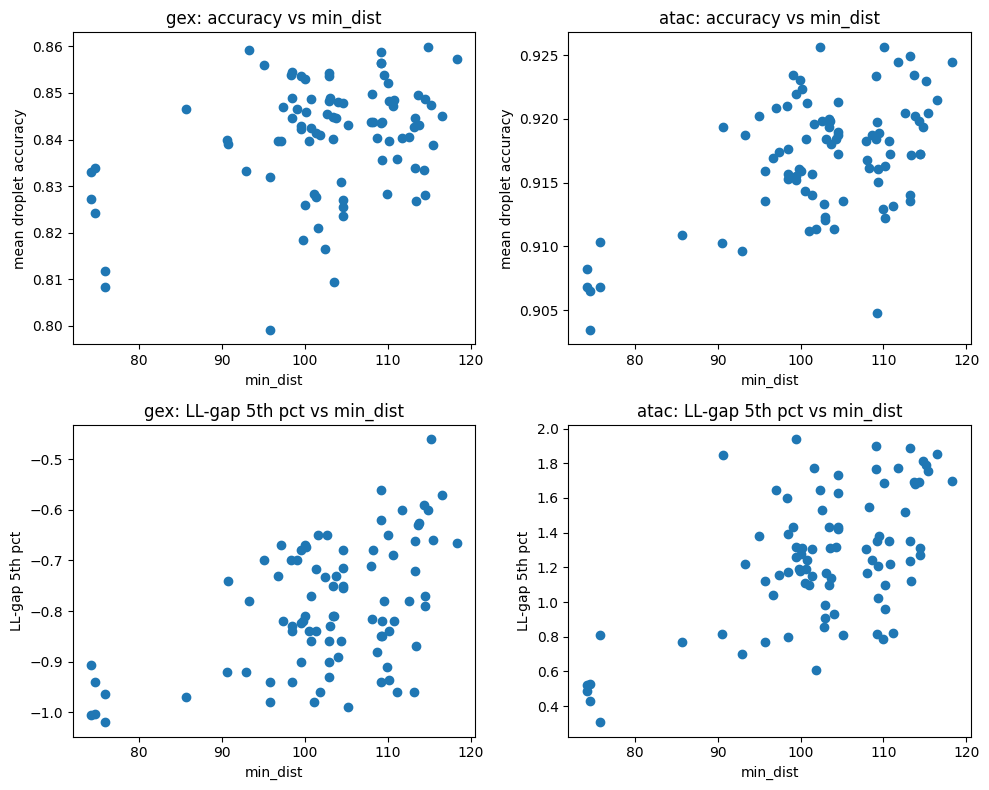

In [11]:
### quick plots: margin/accuracy vs min_dist, per modality
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for col, modality in enumerate(['gex', 'atac']):
    sub = summary[summary['modality'] == modality]
    axes[0, col].scatter(sub['min_dist'], sub['accuracy'])
    axes[0, col].set_title(f'{modality}: accuracy vs min_dist')
    axes[0, col].set_xlabel('min_dist'); axes[0, col].set_ylabel('mean droplet accuracy')

    axes[1, col].scatter(sub['min_dist'], sub['ll_gap_p5'])
    axes[1, col].set_title(f'{modality}: LL-gap 5th pct vs min_dist')
    axes[1, col].set_xlabel('min_dist'); axes[1, col].set_ylabel('LL-gap 5th pct')
plt.tight_layout()
plt.show()

In [12]:
### write pool-level summary checkpoint
outdir = f'{projdir}/csv/ambisim'
summary.to_csv(f'{outdir}/pool_summary.csv', sep='\t', index=False)

In [13]:
!date

Mon Sep 14 07:49:52 PDT 2026
